# EduPulse — Student Dropout Analysis

## Business Goal

Find the factors linked with student dropout and understand how dropout students are different from students who graduate.

## Business Problem


Why are some students dropping out, and what is different between dropout students and graduate students?

## 2. Data Loading & Initial Overview

### 2.1 Import Some Libaries

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency


### 2.2 MySQL Connections

In [2]:
passw = 'Neer@j143'
engine = create_engine(
    "mysql+pymysql://",
    connect_args={
        "host": "localhost",
        "user": "root",
        "password": passw,
        "database": "edupluse"
    }
)

print("MySQL connection successful!")

MySQL connection successful!


### 2.3 Load Datasets

In [3]:
file_path = "D:/Project/AI_Excel_Analytics_Agent/data/student_cleaned.csv"
student_data = pd.read_csv(file_path)
df = student_data.copy()

### 2.4  Shape

In [4]:
print("Shape:",df.shape)

Shape: (4424, 35)


### 2.5 First five rows

In [5]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mothers qualification,Fathers qualification,Mothers occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,Single,2nd phase—general contingent,5,Animation and Multimedia Design,Daytime,Secondary education,Portuguese,Higher Education—doctorate (3rd cycle),Other—11th Year of Schooling,Street vendors (except food) and street servic...,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,International student (bachelor),1,Tourism,Daytime,Secondary education,Portuguese,Higher Education—doctorate (3rd cycle),Higher Education—degree,Street vendors (except food) and street servic...,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1st phase—general contingent,5,Communication Design,Daytime,Secondary education,Portuguese,Higher Education—doctorate (3rd cycle),Basic education 1st cycle (4th/5th year) or eq...,Street vendors (except food) and street servic...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,2nd phase—general contingent,2,Journalism and Communication,Daytime,Secondary education,Portuguese,Higher Education—doctorate (3rd cycle),Basic education 1st cycle (4th/5th year) or eq...,Street vendors (except food) and street servic...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,Over 23 years old,1,Social Service (evening attendance),Evening,Secondary education,Portuguese,Higher Education—doctorate (3rd cycle),Basic Education 2nd Cycle (6th/7th/8th Year) o...,Street vendors (except food) and street servic...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Data Quality Check

### 3.1 Information about Datasets

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   object 
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   object 
 4   Daytime/evening attendance                      4424 non-null   object 
 5   Previous qualification                          4424 non-null   object 
 6   Nationality                                     4424 non-null   object 
 7   Mothers qualification                           4424 non-null   object 
 8   Fathers qualification                           4424 non-null   object 
 9   Mothers occupation                       

### 3.2 Missing Values

In [7]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nationality                                       0
Mothers qualification                             0
Fathers qualification                             0
Mothers occupation                                0
Fathers occupation                                0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

### 3.3 Duplicate Rows

In [8]:
print("No. of Duplicates:",df.duplicated().sum())

No. of Duplicates: 6


### 3.4 Categorical Validation

In [101]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Marital status
Marital status
Single                 3919
Married                 379
Divorced                 91
Common-law marriage      25
Legally separated         6
Widower                   4
Name: count, dtype: int64

Application mode
Application mode
1st phase—general contingent                           1708
2nd phase—general contingent                            872
Over 23 years old                                       785
Change in course                                        312
Technological specialization diploma holders            213
Holders of other higher courses                         139
3rd phase—general contingent                            124
Transfer                                                 77
Change in institution/course                             59
1st phase—special contingent (Madeira Island)            38
Short cycle diploma holders                              35
International student (bachelor)                         30
1st phase—special co

### 3.5 Numerical Validation

In [102]:
numerical_columns = df.select_dtypes(include="number").columns

for col in numerical_columns:
    print(
        f"{col}: "
        f"Min = {df[col].min()}, "
        f"Max = {df[col].max()}, "
        f"Negative values = {(df[col] < 0).sum()}"
    )

Application order: Min = 0, Max = 9, Negative values = 0
Age at enrollment: Min = 17, Max = 70, Negative values = 0
Curricular units 1st sem (credited): Min = 0, Max = 20, Negative values = 0
Curricular units 1st sem (enrolled): Min = 0, Max = 26, Negative values = 0
Curricular units 1st sem (evaluations): Min = 0, Max = 45, Negative values = 0
Curricular units 1st sem (approved): Min = 0, Max = 26, Negative values = 0
Curricular units 1st sem (grade): Min = 0.0, Max = 18.875, Negative values = 0
Curricular units 1st sem (without evaluations): Min = 0, Max = 12, Negative values = 0
Curricular units 2nd sem (credited): Min = 0, Max = 19, Negative values = 0
Curricular units 2nd sem (enrolled): Min = 0, Max = 23, Negative values = 0
Curricular units 2nd sem (evaluations): Min = 0, Max = 33, Negative values = 0
Curricular units 2nd sem (approved): Min = 0, Max = 20, Negative values = 0
Curricular units 2nd sem (grade): Min = 0.0, Max = 18.57142857, Negative values = 0
Curricular units 2nd

### 3.6 Outlier Detection

In [9]:
def outlier_detection(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    lower =  Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return round(lower,2) , round(upper,2) 

In [10]:
column_mapping = {
    'Age': 'Age at enrollment',
    '1st sem grade': 'Curricular units 1st sem (grade)',
    '1st sem approved': 'Curricular units 1st sem (approved)',
    '2nd sem grade': 'Curricular units 2nd sem (grade)',
    '2nd sem approved': 'Curricular units 2nd sem (approved)',
}

rows = []
for display_name, actual_column in column_mapping.items():
    lower, upper = outlier_detection(df[actual_column])
    rows.append({
        'Feature': display_name,
        'Lower Bound': lower,
        'Upper Bound': upper
    })

outlier_df = pd.DataFrame(rows)

outlier_df

,Feature,Lower Bound,Upper Bound
0,Age,10.00,34.00
1,1st sem grade,7.40,17.00
2,1st sem approved,-1.50,10.50
3,2nd sem grade,6.88,17.21
4,2nd sem approved,-4.00,12.00


### 3.7 Logical Consistency Check

A logical consistency check identified **676 students** with a recorded grade of
0 in both the 1st and 2nd semesters.

Among these students, **546 (80.77%) were Dropout, 75 (11.09%) were Graduate,
and 55 (8.14%) were Enrolled**.

The group had an average of **0 approved curricular units** in both semesters,
while the average enrolled units were 4.09 in the 1st semester and 4.18 in the
2nd semester. The average number of evaluations was 3.55 in the 1st semester
and 2.93 in the 2nd semester.

Because some students with zero recorded grades had a Graduate outcome, the
zero value was not automatically interpreted as a conventional failed grade.
Related academic variables were therefore considered before drawing conclusions
from the grade variable.

In [103]:
zero_grade = df[ (df['Curricular units 1st sem (grade)'] == 0)  & (df['Curricular units 2nd sem (grade)'] == 0)]
counts = zero_grade['Target'].value_counts()
percentage = zero_grade['Target'].value_counts(normalize = True) * 100

pd.DataFrame(
    {
        'Count':counts,
        'Percentage(%)':percentage 
    }
)

,Count,Percentage(%)
Target,,
Dropout,546,80.769231
Graduate,75,11.094675
Enrolled,55,8.136095


In [92]:
data = {
    'Metric': ['Approved units', 'Evaluations', 'Without evaluations', 'Enrolled units'],
    '1st Sem': [
        round(zero_grade['Curricular units 1st sem (approved)'].mean(), 2),
        round(zero_grade['Curricular units 1st sem (evaluations)'].mean(), 2),
        round(zero_grade['Curricular units 1st sem (without evaluations)'].mean(), 2),
        round(zero_grade['Curricular units 1st sem (enrolled)'].mean(), 2)
    ],
    '2nd Sem': [
        round(zero_grade['Curricular units 2nd sem (approved)'].mean(), 2),
        round(zero_grade['Curricular units 2nd sem (evaluations)'].mean(), 2),
        round(zero_grade['Curricular units 2nd sem (without evaluations)'].mean(), 2),
        round(zero_grade['Curricular units 2nd sem (enrolled)'].mean(), 2)
    ]
}

zero_grade_avg = pd.DataFrame(data)
zero_grade_avg

,Metric,1st Sem,2nd Sem
0,Approved units,0.00,0.00
1,Evaluations,3.55,2.93
2,Without evaluations,0.23,0.23
3,Enrolled units,4.09,4.18


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Distribution

In [11]:
target_summary = (
    df["Target"]
    .value_counts()
    .to_frame("Total Students")
)

target_summary["Percentage"] = (
    target_summary["Total Students"]
    / len(df) * 100
).round(2)

target_summary

,Total Students,Percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


### 4.2 Descriptive Statistics 

In [12]:
numeric_cols = [
    "Age at enrollment",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)"
]

summary_stats = df[numeric_cols].describe().T.round(2)

summary_stats

,count,mean,std,min,25%,50%,75%,max
Age at enrollment,4424.0,23.27,7.59,17.0,19.00,20.00,25.00,70.00
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.0,11.00,12.29,13.40,18.88
Curricular units 2nd sem (grade),4424.0,10.23,5.21,0.0,10.75,12.20,13.33,18.57
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.0,3.00,5.00,6.00,26.00
Curricular units 2nd sem (approved),4424.0,4.44,3.01,0.0,2.00,5.00,6.00,20.00


### 4.3 Distribution Analysis

#### Age at Enrollment

**Business Question:**  
How is the age of students distributed at the time of enrollment?

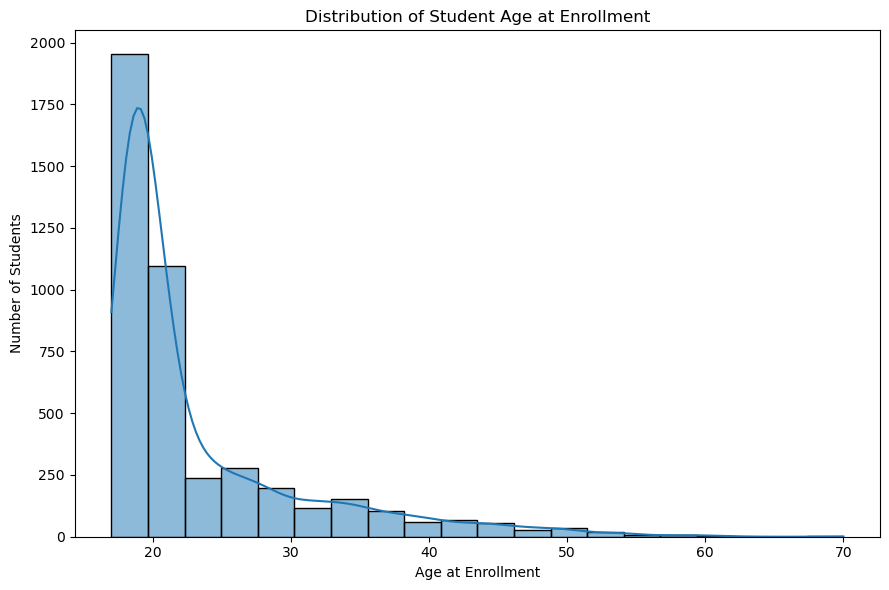

In [13]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="Age at enrollment",
    bins=20,
    kde=True
)

plt.title("Distribution of Student Age at Enrollment")
plt.xlabel("Age at Enrollment")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

**Interpretation:**

Most students enrolled between the ages of **17 and 24**, with the highest concentration around the late-teen to early-20s range. The number of students decreases as age increases, creating a clear **right-skewed distribution**. There are relatively few students above 30, with a long tail extending to around 70 years. The 70-year observation is unusual compared with the rest of the dataset, so it should be reviewed as a statistical outlier rather than automatically treated as an error.

**Business Relevance:**

Age is useful for understanding whether dropout patterns differ across student age groups. This distribution also provides context for the age-group dropout analysis done earlier.

### Distribution 2 — First Semester Grade

**Business Question:**  
How are students' first-semester grades distributed?

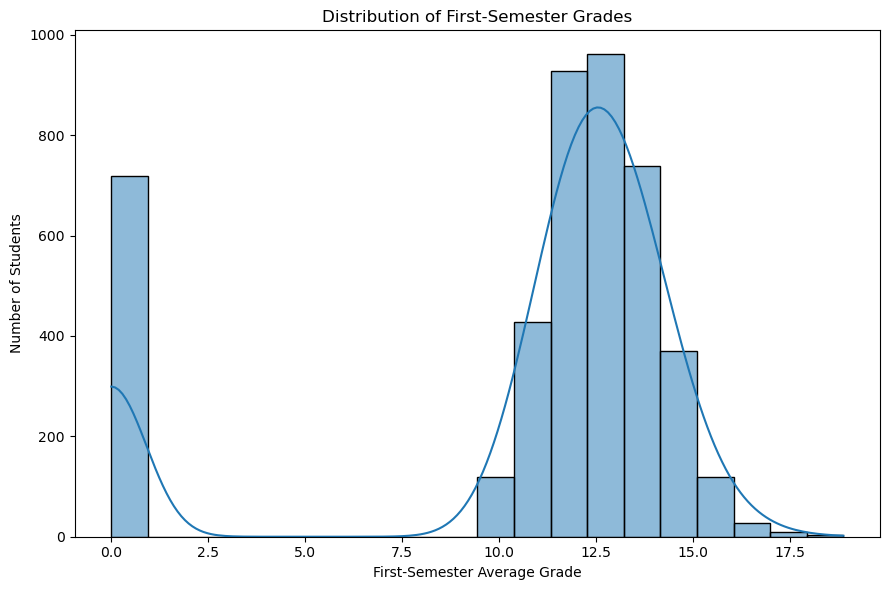

In [14]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="Curricular units 1st sem (grade)",
    bins=20,
    kde=True
)

plt.title("Distribution of First-Semester Grades")
plt.xlabel("First-Semester Average Grade")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

**Interpretation:**

Most first-semester grades are concentrated between around **10 and 15**, with the highest concentration around **12–13**. A noticeable group of students has a grade of **0**, creating a separate peak on the left side of the distribution. Very few students have grades above 16, so the distribution is mainly concentrated in the middle range with a smaller group at the lower end.

**Business Relevance:**

The grade distribution provides a baseline for understanding students' academic performance. The separate group with a grade of 0 is worth investigating further when comparing academic performance with dropout outcomes.

### Distribution 3 — Second Semester Grade

**Business Question:**  
How are students' second-semester grades distributed?

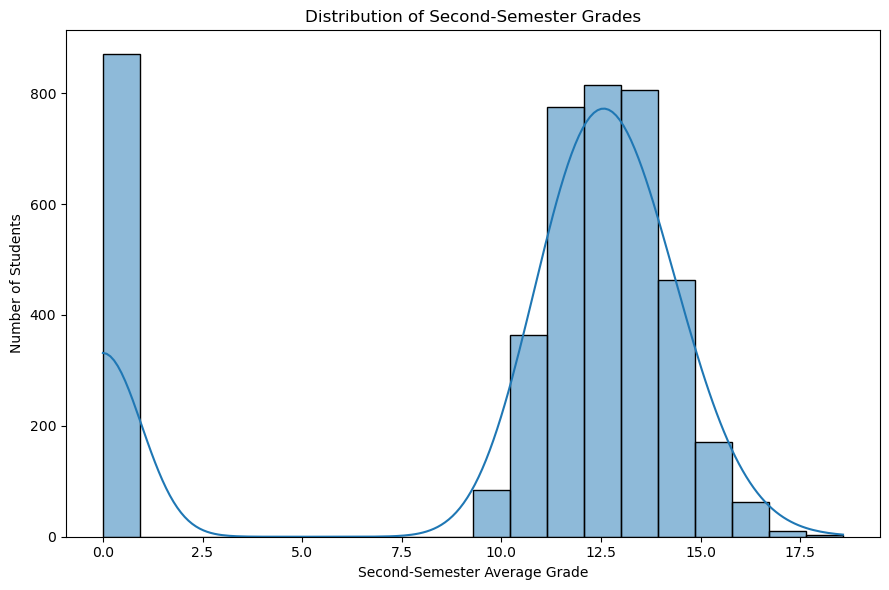

In [15]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="Curricular units 2nd sem (grade)",
    bins=20,
    kde=True
)

plt.title("Distribution of Second-Semester Grades")
plt.xlabel("Second-Semester Average Grade")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

**Interpretation:**

Most second-semester grades are concentrated between around **10 and 15**, with the highest concentration around **12–14**. A large group of students has a grade of **0**, which forms a separate peak at the lower end of the distribution. Very few students have grades above 16, so the main group remains concentrated in the middle range. Compared with the first-semester distribution, the same pattern of a large zero-grade group and a main cluster around 10–15 can be seen.

**Business Relevance:**

The distribution provides a clear view of students' second-semester academic performance. The large group with a grade of 0 is particularly relevant for further analysis because the earlier dropout comparison showed much lower average second-semester grades among dropout students.

### Distribution 4 — First Semester Approved Units

**Business Question:**  
How many curricular units do students typically approve in the first semester?

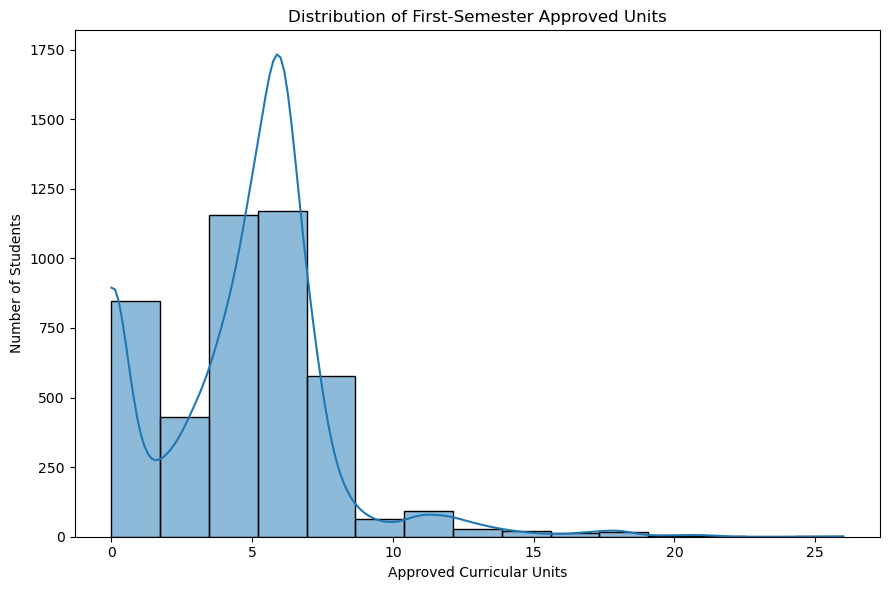

In [16]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="Curricular units 1st sem (approved)",
    bins=15,
    kde=True
)

plt.title("Distribution of First-Semester Approved Units")
plt.xlabel("Approved Curricular Units")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

**Interpretation:**

Most students approved between **4 and 7 curricular units** in the first semester, with the highest concentration around **5–6 units**. A noticeable number of students approved very few or zero units, while only a small number approved more than 10 units. The distribution is concentrated toward the lower-to-middle range, with a long tail extending to higher numbers of approved units.

**Business Relevance:**

This distribution helps establish the overall level of academic progress in the first semester. Students approving very few units may be worth further investigation when studying patterns associated with dropout.

### Distribution 5 — First Semester Approved Units

**Business Question:**  
How many curricular units do students typically approve in the second semester?

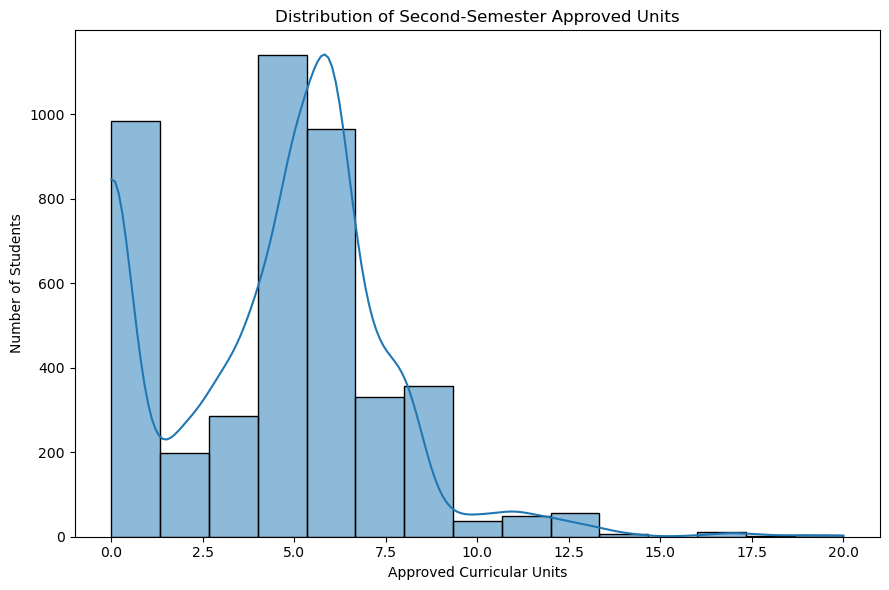

In [17]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="Curricular units 2nd sem (approved)",
    bins=15,
    kde=True
)

plt.title("Distribution of Second-Semester Approved Units")
plt.xlabel("Approved Curricular Units")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

**Interpretation:**

Most students approved around **4 to 7 curricular units** in the second semester, with the highest concentration around **5 to 6 units**. A large group of students also approved **0 units**, which is another noticeable part of the distribution. The number of students decreases considerably as the number of approved units increases, with relatively few students approving more than 10 units. The distribution therefore has a concentration in the lower-to-middle range with a long tail toward higher numbers of approved units.

**Business Relevance:**

This distribution gives a baseline view of students' academic progress in the second semester. Students with very few or zero approved units can be examined further to understand whether this pattern is associated with dropout outcomes.

## 5. Target - wise Comparison

In [18]:
target_df = pd.DataFrame(df.groupby("Target")[['Age at enrollment',
'Curricular units 2nd sem (grade)',                                           'Curricular units 2nd sem (approved)',                                          'Curricular units 2nd sem (evaluations)',                                               'Curricular units 2nd sem (without evaluations)']].mean().round(2))
target_df = target_df.rename(columns = {
    'Age at enrollment':'Average_age',
    'Curricular units 2nd sem (grade)':'Average_grade',
    'Curricular units 2nd sem (approved)':'Average_approved_units',
    'Curricular units 2nd sem (evaluations)':'Average_evaluations',
    'Curricular units 2nd sem (without evaluations)':'Average_units_without_evaluation'
})
target_df

,Average_age,Average_grade,Average_approved_units,Average_evaluations,Average_units_without_evaluation
Target,,,,,
Dropout,26.07,5.90,1.94,7.17,0.24
Enrolled,22.37,11.12,4.06,9.44,0.19
Graduate,21.78,12.70,6.18,8.14,0.08


## 6. SQL Business Analysis

SQL was used to answer the main business questions related to student
dropout and student outcomes.

The complete SQL analysis, including the business questions and queries,
is available in:

**`sql/dropout_analysis.sql`**

The analysis covered:

- Overall student outcome distribution
- Financial factors and dropout
- Tuition fee status
- Debtor status
- Scholarship status
- Course-wise dropout patterns
- Attendance patterns
- Academic performance
- Academic progress
- Age and other student characteristics
- Combined academic and financial segments

The SQL analysis helped identify the main patterns and relationships in the
data. These results were later used for visualization, statistical analysis,
and the final business findings.

## 7. Business Visualization

### Visualization 1 — Overall Target Distribution

**Business Question:**  
What is the distribution of students across Dropout, Graduate, and Enrolled outcomes?

In [19]:
target_summary = (
    df["Target"]
    .value_counts()
    .to_frame("Total Students")
)

target_summary["Percentage"] = (
    target_summary["Total Students"] / len(df) * 100
).round(2)

target_summary

,Total Students,Percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


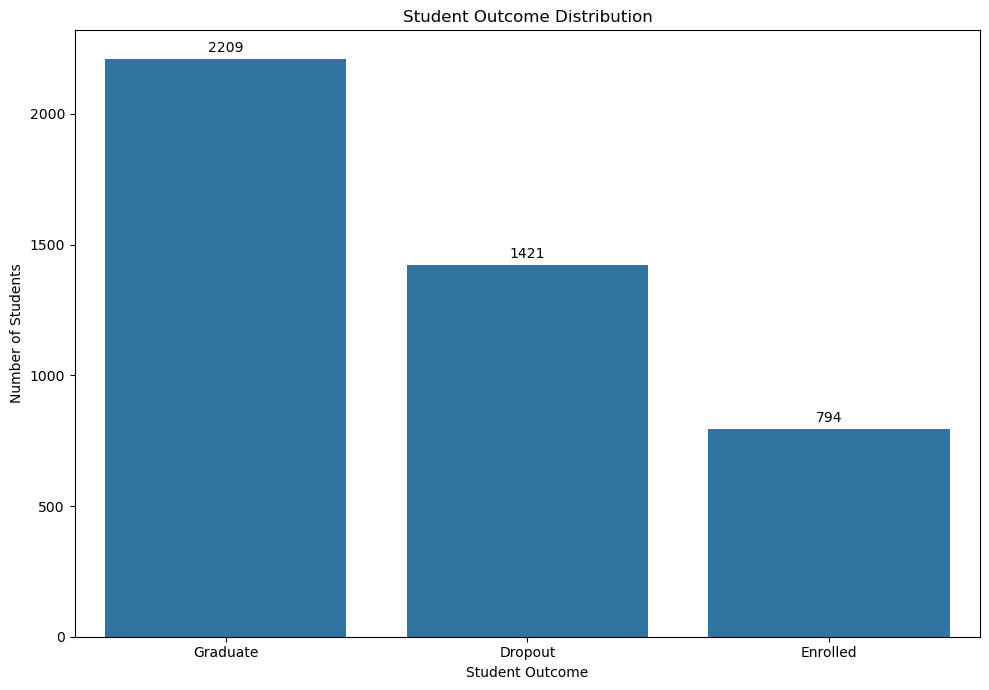

In [20]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=target_summary.reset_index(),
    x="Target",
    y="Total Students"
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Student Outcome Distribution")
plt.xlabel("Student Outcome")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

#### Interpretation:

The dataset contains students across three outcome categories:
Dropout, Graduate, and Enrolled.

Dropout students represent 32.12% of the total student population.
This provides the overall context for the subsequent analysis, where
we examine the academic, financial, demographic, and course-related
patterns associated with student dropout.

### Visualization 2 — Financial Factors & Dropout Rate

**Business Question:**  
Are financial factors associated with different student dropout rates?

In [21]:
query_financial = """
SELECT
    'Debtor' AS Factor,
    Debtor AS Status,
    ROUND(
        SUM(Target = 'Dropout') * 100.0 / COUNT(*),
        2
    ) AS `Dropout Rate`
FROM student
GROUP BY Debtor

UNION ALL

SELECT
    'Tuition Fees' AS Factor,
    `Tuition fees up to date` AS Status,
    ROUND(
        SUM(Target = 'Dropout') * 100.0 / COUNT(*),
        2
    ) AS `Dropout Rate`
FROM student
GROUP BY `Tuition fees up to date`

UNION ALL

SELECT
    'Scholarship' AS Factor,
    `Scholarship holder` AS Status,
    ROUND(
        SUM(Target = 'Dropout') * 100.0 / COUNT(*),
        2
    ) AS `Dropout Rate`
FROM student
GROUP BY `Scholarship holder`;
"""

financial_summary = pd.read_sql(
    query_financial,
    engine
)

financial_summary

,Factor,Status,Dropout Rate
0,Debtor,No,28.28
1,Debtor,Yes,62.03
2,Tuition Fees,Yes,24.74
3,Tuition Fees,No,86.55
4,Scholarship,No,38.71
5,Scholarship,Yes,12.19


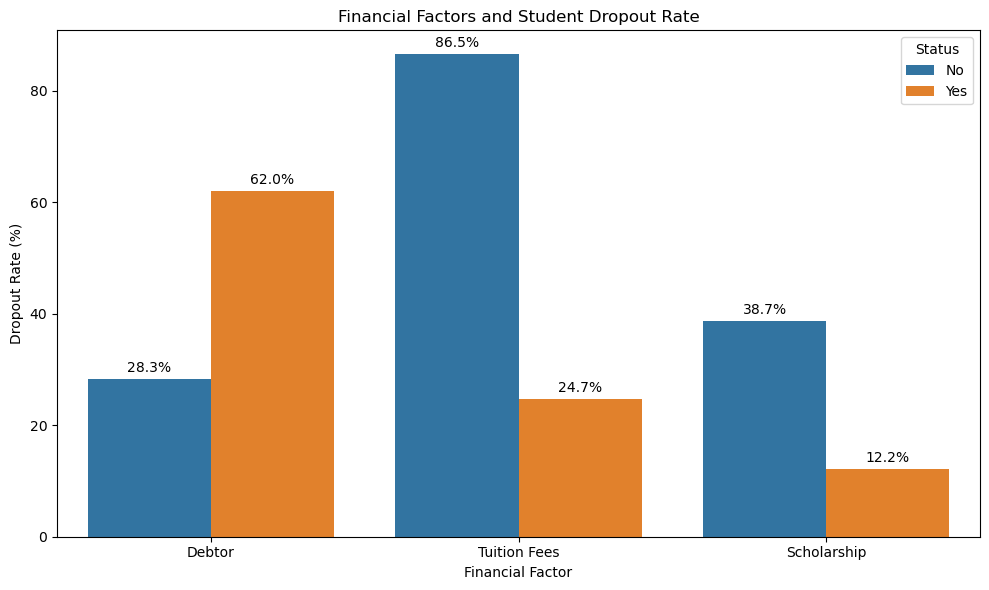

In [22]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=financial_summary,
    x="Factor",
    y="Dropout Rate",
    hue="Status"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Financial Factors and Student Dropout Rate")
plt.xlabel("Financial Factor")
plt.ylabel("Dropout Rate (%)")
plt.legend(title="Status")

plt.tight_layout()
plt.show()

#### Interpretation:

The chart shows that dropout rates differ across the three financial
factors.

- Among students classified as debtors, the observed dropout rate was
  62.0%, compared with 28.3% among non-debtors.
- Students whose tuition fees were not up to date had an observed
  dropout rate of 86.5%, compared with 24.7% among students whose
  tuition fees were up to date.
- Scholarship holders had an observed dropout rate of 12.2%, compared
  with 38.7% among non-scholarship holders.

Among the three factors, tuition fee status shows the largest difference
in observed dropout rates between its two groups.

These results indicate that financial factors are associated with
different dropout patterns in the dataset. However, these are observed
associations and should not be interpreted as evidence that financial
factors directly cause student dropout.

### Visualization 3 — Course-wise Dropout Rate

**Business Question:**  
Which courses have higher observed dropout rates?

In [23]:
query_course = """
SELECT
    Course,
    COUNT(*) AS `Total Students`,
    SUM(Target = 'Dropout') AS `Dropout Students`,
    ROUND(
        SUM(Target = 'Dropout') * 100.0 / COUNT(*),
        2
    ) AS `Dropout Rate`
FROM student
GROUP BY Course
ORDER BY Course ASC;
"""

course_summary = pd.read_sql(query_course , engine)
course_summary

,Course,Total Students,Dropout Students,Dropout Rate
0,Advertising and Marketing Management,268,95.0,35.45
1,Agronomy,210,86.0,40.95
2,Animation and Multimedia Design,215,82.0,38.14
3,Basic Education,192,85.0,44.27
4,Biofuel Production Technologies,12,8.0,66.67
5,Communication Design,226,51.0,22.57
6,Equiniculture,141,78.0,55.32
7,Informatics Engineering,170,92.0,54.12
8,Journalism and Communication,331,101.0,30.51
9,Management,380,134.0,35.26


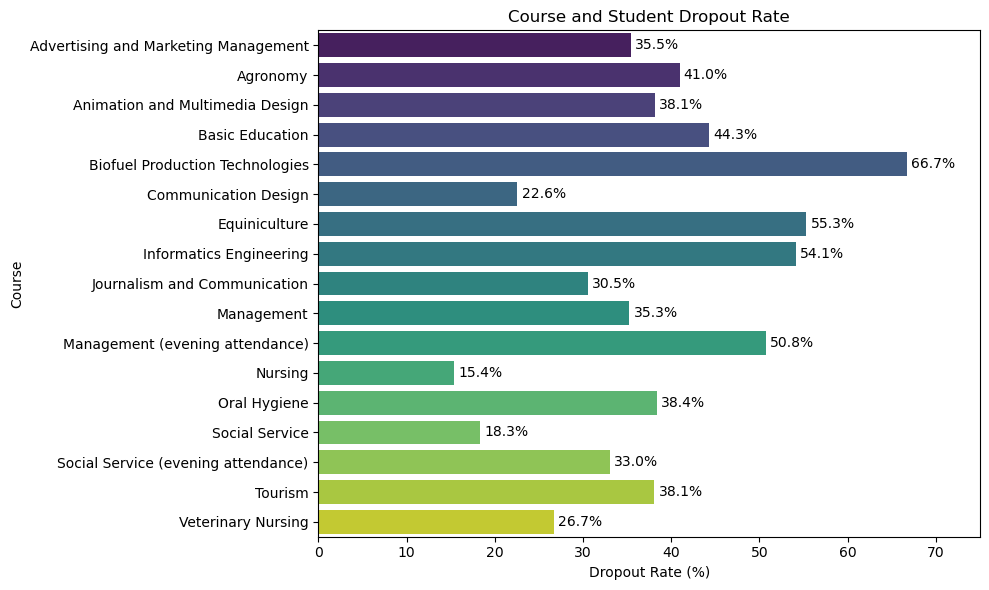

In [24]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=course_summary,
    y="Course",
    x="Dropout Rate",
    hue = "Course",
    legend = False,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Course and Student Dropout Rate")
plt.xlabel("Dropout Rate (%)")
plt.ylabel("Course")
plt.xlim(0,75)


plt.tight_layout()
plt.show()

#### Interpretation:

The chart shows substantial variation in observed dropout rates across
different courses.

- Biofuel Production Technologies had the highest observed dropout rate
  at 66.7%.
- Equinculture had a dropout rate of 55.3%, followed by Informatics
  Engineering at 54.1%.
- Management (evening attendance) also showed a relatively high dropout
  rate of 50.8%.
- Basic Education had a dropout rate of 44.3%.
- Agronomy had a dropout rate of 41.0%.
- Nursing had the lowest observed dropout rate at 15.4%, followed by
  Social Service at 18.3% and Communication Design at 22.6%.

Overall, the results indicate that dropout rates vary considerably
across courses. Some courses show substantially higher observed dropout
rates than others.

#### Business Implication:

Courses with higher observed dropout rates may require further
investigation to understand whether differences in student
characteristics, academic performance, financial conditions, or other
factors are associated with these patterns.

> Note: Course-level differences represent observed associations in this
> dataset and do not imply that the course itself causes student dropout.

### Visualization 4 — Academic Performance

**Business Question:**  
How does academic performance differ between dropout and graduate students?

In [25]:
grade_query = """
SELECT Target,
ROUND(AVG(`Curricular units 1st sem (grade)`),2) AS `Average 1st sem Grade`,
ROUND(AVG(`Curricular units 2nd sem (grade)`),2) AS `Average 2nd sem Grade`
FROM student
WHERE Target IN ('Graduate','Dropout')
GROUP BY Target ;
"""

grade_summary = pd.read_sql(grade_query,engine)
grade_summary

,Target,Average 1st sem Grade,Average 2nd sem Grade
0,Graduate,12.64,12.7
1,Dropout,7.26,5.9


In [26]:
df_melted = grade_summary.melt(id_vars = 'Target',
                               var_name ='Semster',
                               value_name = 'Grade')
df_melted

,Target,Semster,Grade
0,Graduate,Average 1st sem Grade,12.64
1,Dropout,Average 1st sem Grade,7.26
2,Graduate,Average 2nd sem Grade,12.70
3,Dropout,Average 2nd sem Grade,5.90


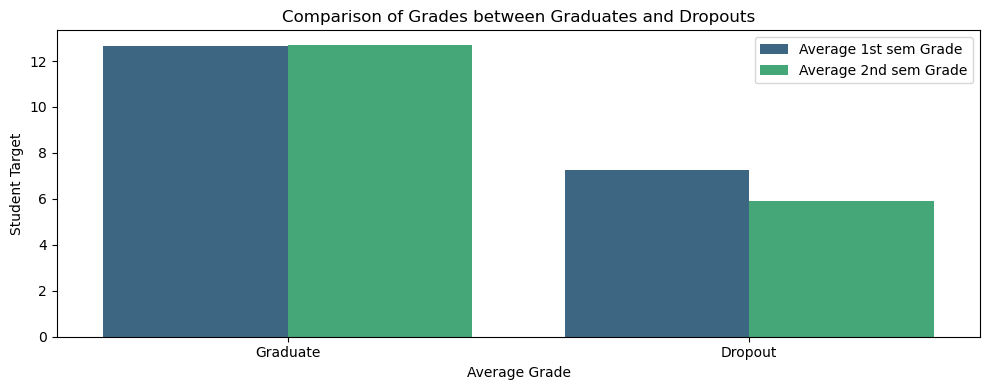

In [27]:
plt.figure(figsize = (10,4))

sns.barplot(data = df_melted,
            y = 'Grade',
            x = 'Target',
            hue = 'Semster',
             palette="viridis")


plt.title("Comparison of Grades between Graduates and Dropouts")
plt.xlabel('Average Grade')
plt.ylabel('Student Target')
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation:

The chart shows a clear difference in recorded academic performance between
Graduate and Dropout students.

- Graduate students had an average first-semester grade of approximately 12.66,
  compared with 7.07 for Dropout students.
- In the second semester, Graduate students had an average grade of approximately
  12.70, while Dropout students had an average of 5.90.

The Dropout group showed a decline in average recorded grade from the first to the
second semester, while the Graduate group remained relatively stable.

#### Business Implication:

Lower recorded academic performance, particularly in the second semester, is
strongly associated with student dropout in this dataset. Students showing
persistently lower or declining academic performance could be considered for
earlier academic monitoring and support.

**Note:** These results show an observed association between recorded academic
performance and dropout status. They do not establish that low academic
performance directly causes dropout. A sensitivity analysis also showed that
zero-grade observations affect the magnitude of the difference, but the
Dropout–Graduate difference remained statistically significant after excluding
students with zero grades in both semesters.

### Visualization 5 — Academic Progress

**Business Question:**  
Do dropout students successfully complete fewer curricular units than graduate students?

In [28]:
approved_unit_query = """
SELECT Target,
ROUND(AVG(`Curricular units 1st sem (approved)`),2) AS `Average of 1st sem approved units`,
ROUND(AVG(`Curricular units 2nd sem (approved)`),2) AS `Average of 2nd sem approved units`
FROM student
WHERE Target IN ('Graduate','Dropout')
GROUP BY Target;
"""

approved_summary = pd.read_sql(approved_unit_query , engine)

df_melted_approved = approved_summary.melt(id_vars = 'Target',
                               var_name ='Semster',
                               value_name = 'Approved Units')
df_melted_approved

,Target,Semster,Approved Units
0,Graduate,Average of 1st sem approved units,6.23
1,Dropout,Average of 1st sem approved units,2.55
2,Graduate,Average of 2nd sem approved units,6.18
3,Dropout,Average of 2nd sem approved units,1.94


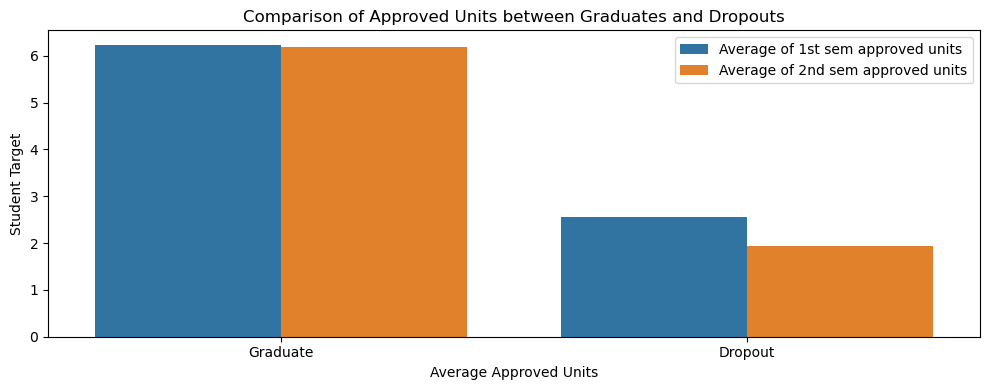

In [29]:
plt.figure(figsize=(10,4))

sns.barplot(data = df_melted_approved,
            x = 'Target',
            y = 'Approved Units',
            hue = 'Semster')


plt.title("Comparison of Approved Units between Graduates and Dropouts")
plt.xlabel('Average Approved Units')
plt.ylabel('Student Target')
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation:

The chart shows a substantial difference in the number of curricular units
approved by Graduate and Dropout students.

- Graduate students approved an average of approximately 6.25 units in the
  first semester and 6.20 units in the second semester.
- Dropout students approved an average of approximately 2.55 units in the
  first semester and 1.93 units in the second semester.

Graduate students maintained a relatively stable level of academic progress,
while Dropout students approved fewer units and showed a further decline in
the second semester.

#### Business Implication:

Lower academic progress is strongly associated with dropout status in this
dataset. Students consistently approving fewer curricular units could be
considered for earlier academic monitoring and academic support.

> **Note:** These results represent observed associations and do not establish
> that lower academic progress directly causes dropout.

### Visualization 6 — Age Group & Dropout Rate

**Business Question:**  
How does the observed dropout rate vary across different age groups?

In [30]:
age_group_query = """
SELECT
    `Age Group`,
    COUNT(*) AS `Total Students`,
    SUM(Target = 'Dropout') AS `Dropout Students`,
    ROUND(SUM(Target = 'Dropout') * 100.0 / COUNT(*),2) AS `Drop Rate`
FROM student
GROUP BY  `Age Group`
ORDER BY `Age Group`;
"""
age_group_summary = pd.read_sql(age_group_query ,engine)


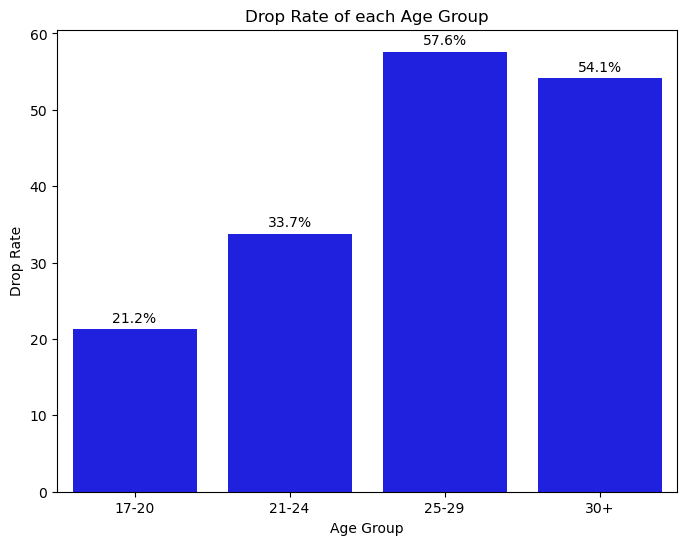

In [31]:
plt.figure(figsize = (8,6))

ax = sns.barplot(data = age_group_summary,
            x = 'Age Group',
            y = 'Drop Rate',
            color = 'blue')

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title('Drop Rate of each Age Group')
plt.xlabel('Age Group')
plt.ylabel('Drop Rate')

plt.show()


#### Interpretation:

The chart shows clear differences in observed dropout rates across the age
groups.

- Students aged 17–20 had an observed dropout rate of 21.2%.
- Students aged 21–24 had an observed dropout rate of 33.7%.
- Students aged 25–29 had an observed dropout rate of 57.6%.
- Students aged 30+ had an observed dropout rate of 54.1%.

The 25–29 age group had the highest observed dropout rate at 57.6%, followed
by the 30+ group at 54.1%. The 17–20 group had the lowest observed dropout
rate at 21.2%.

#### Business Implication:

Age groups show different dropout patterns in this dataset. The higher
observed dropout rates among older student groups may warrant further
investigation into the academic, financial, or other factors associated with
these differences.

> **Note:** These results represent observed associations and do not establish
> that age itself directly causes student dropout.

### Visualization 7 — Final Risk Segment

**Business Question:**  
Among students with weaker academic performance, how does the observed dropout rate differ by financial status?

In [32]:
query_risk_segment = """
SELECT Debtor , COUNT(*) AS `Total Students` ,
SUM(Target = 'Dropout') AS `Dropout Students`,
ROUND(SUM(Target = 'Dropout') * 100.0 / COUNT(*),2) AS `Dropout Rate`
FROM student
WHERE (`Curricular units 2nd sem (grade)` < 8)
GROUP BY Debtor
ORDER BY `Dropout Rate` DESC;
"""
risk_segment = pd.read_sql(query_risk_segment,engine)

In [33]:
risk_segment

,Debtor,Total Students,Dropout Students,Dropout Rate
0,Yes,167,149.0,89.22
1,No,703,578.0,82.22


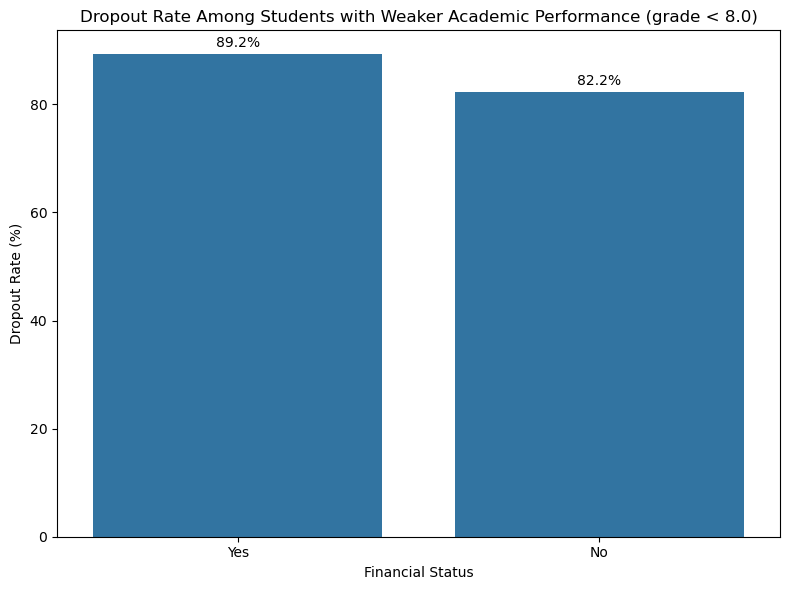

In [34]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=risk_segment,
    x="Debtor",
    y="Dropout Rate"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Dropout Rate Among Students with Weaker Academic Performance (grade < 8.0)")
plt.xlabel("Financial Status")
plt.ylabel("Dropout Rate (%)")

plt.tight_layout()
plt.show()

### Interpretation:

The chart focuses on students with weaker academic performance, defined as a
second-semester grade below 8.

Among these students:

- Students with financial difficulty (Debtor = Yes) had an observed dropout
  rate of 89.2%.
- Students without financial difficulty (Debtor = No) had an observed dropout
  rate of 82.2%.

Both groups had very high observed dropout rates. The dropout rate was
7.0 percentage points higher among students with financial difficulty.

### Business Implication:

Students with weaker academic performance may require earlier academic
monitoring and support. Financial status can provide additional context when
identifying segments for closer monitoring and support.

> **Note:** These results represent observed associations in the dataset.
> They should not be interpreted as evidence that weak academic performance
> or financial difficulty directly causes dropout.

## 8. Statistical Analysis

### 8.1 Correlation  Analysis

#### 1st Sem Grade ↔ 2nd Sem Grade

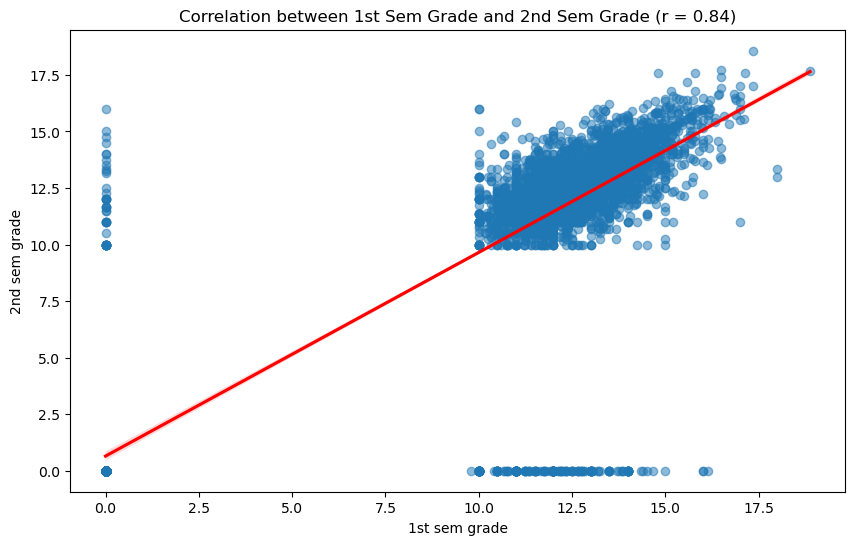

In [35]:
correlation = df['Curricular units 1st sem (grade)'].corr(df['Curricular units 2nd sem (grade)'])


plt.figure(figsize = (10,6))
sns.regplot(data = df,
           x = 'Curricular units 1st sem (grade)',
           y = 'Curricular units 2nd sem (grade)',
           scatter_kws = {'alpha':0.5},
           line_kws = {'color':'red'})

plt.title(f'Correlation between 1st Sem Grade and 2nd Sem Grade (r = {correlation:.2f})')
plt.xlabel('1st sem grade')
plt.ylabel('2nd sem grade')

plt.show()

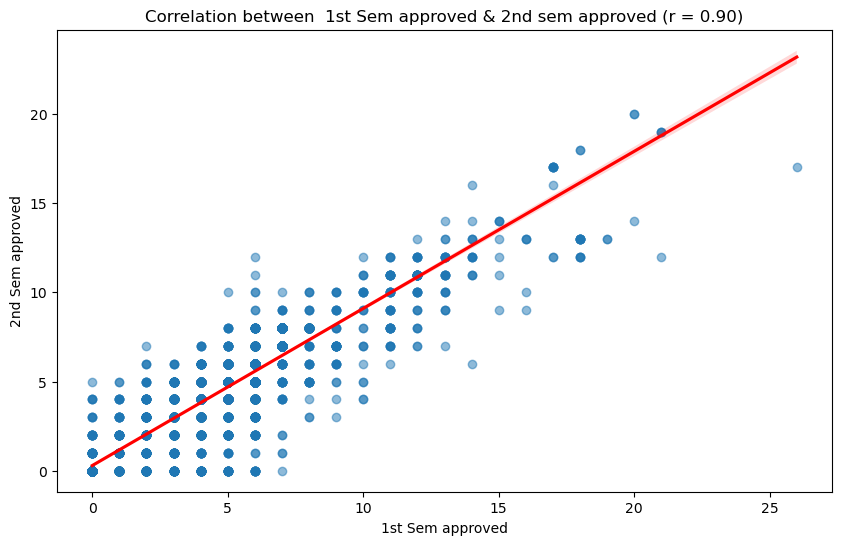

In [36]:
correlation = df['Curricular units 1st sem (approved)'].corr(df['Curricular units 2nd sem (approved)'])


plt.figure(figsize = (10,6))
sns.regplot(data = df,
           x = 'Curricular units 1st sem (approved)',
           y = 'Curricular units 2nd sem (approved)',
           scatter_kws = {'alpha':0.5},
           line_kws = {'color':'red'})

plt.title(f'Correlation between  1st Sem approved & 2nd sem approved (r = {correlation:.2f})')
plt.xlabel('1st Sem approved')
plt.ylabel('2nd Sem approved')

plt.show()

#### Age <--> 2nd sem grade

Correlation coefficient: -0.17


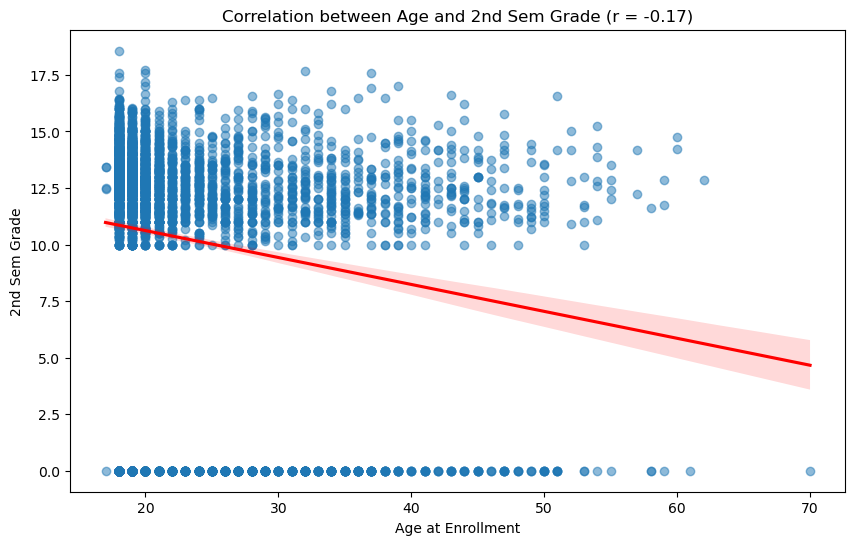

In [37]:
correlation = df['Age at enrollment'].corr(df['Curricular units 2nd sem (grade)'])
print(f"Correlation coefficient: {correlation:.2f}")


plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, 
    x='Age at enrollment', 
    y='Curricular units 2nd sem (grade)', 
    scatter_kws={'alpha':0.5},    
    line_kws={'color':'red'}     
)


plt.title(f'Correlation between Age and 2nd Sem Grade (r = {correlation:.2f})')
plt.xlabel('Age at Enrollment')
plt.ylabel('2nd Sem Grade')

plt.show()

####  Outlier Sestivity Check

#### Correlation without extreme age observation

In [38]:
outlier_df

,Feature,Lower Bound,Upper Bound
0,Age,10.00,34.00
1,1st sem grade,7.40,17.00
2,1st sem approved,-1.50,10.50
3,2nd sem grade,6.88,17.21
4,2nd sem approved,-4.00,12.00


In [39]:
df_cleaned = df[(df['Age at enrollment'] >= 10.0) & (df['Age at enrollment'] <= 34.0)]
df_cleaned.shape

(3983, 35)

Correlation coefficient: -0.19


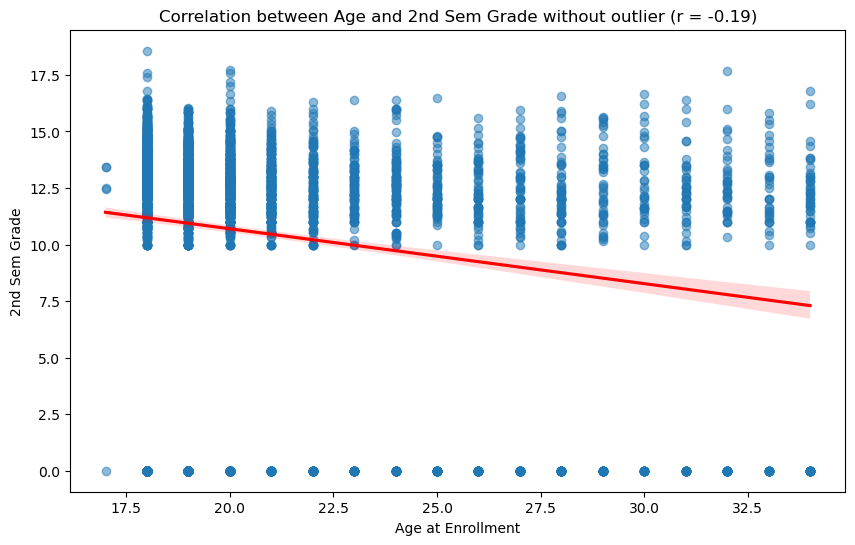

In [40]:
correlation = df_cleaned['Age at enrollment'].corr(df_cleaned['Curricular units 2nd sem (grade)'])
print(f"Correlation coefficient: {correlation:.2f}")


plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_cleaned, 
    x='Age at enrollment', 
    y='Curricular units 2nd sem (grade)', 
    scatter_kws={'alpha':0.5},    
    line_kws={'color':'red'}     
)


plt.title(f'Correlation between Age and 2nd Sem Grade without outlier (r = {correlation:.2f})')
plt.xlabel('Age at Enrollment')
plt.ylabel('2nd Sem Grade')

plt.show()

### 8.2 Zero-Grade Sensitivity Analysis

To assess the impact of students with zero recorded grades in both semesters,
the 2nd-semester grade analysis was performed on the original dataset and
then repeated after excluding students who had zero grades in both semesters.

#### Code Original data

In [104]:
dropout_original = df.loc[
    df["Target"] == "Dropout",
    "Curricular units 2nd sem (grade)"
]

graduate_original = df.loc[
    df["Target"] == "Graduate",
    "Curricular units 2nd sem (grade)"
]

original_dropout_mean = dropout_original.mean()
original_graduate_mean = graduate_original.mean()

print("Original Dropout Mean:", round(original_dropout_mean, 2))
print("Original Graduate Mean:", round(original_graduate_mean, 2))

Original Dropout Mean: 5.9
Original Graduate Mean: 12.7


#### Code zero both semsters exclude

In [105]:
without_zero_grade = df[
    (df["Curricular units 1st sem (grade)"] > 0) |
    (df["Curricular units 2nd sem (grade)"] > 0)
]

In [106]:
dropout_filtered = without_zero_grade.loc[
    without_zero_grade["Target"] == "Dropout",
    "Curricular units 2nd sem (grade)"
]

graduate_filtered = without_zero_grade.loc[
    without_zero_grade["Target"] == "Graduate",
    "Curricular units 2nd sem (grade)"
]

filtered_dropout_mean = dropout_filtered.mean()
filtered_graduate_mean = graduate_filtered.mean()

print("Filtered Dropout Mean:", round(filtered_dropout_mean, 2))
print("Filtered Graduate Mean:", round(filtered_graduate_mean, 2))

Filtered Dropout Mean: 9.58
Filtered Graduate Mean: 13.14


#### Interpretation

Zero-grade observations had a substantial effect on the measured average
2nd-semester grade, particularly for dropout students. After excluding
students with zero recorded grades in both semesters, the dropout average
increased from **5.90 to 9.58**, while the graduate average changed from **12.70
to 13.14**.

### 8.3 Welch's t-test

#### 2nd Semester Grade

**Business Question:**
Is the average 2nd-semester grade significantly different between dropout and graduate students?

**Null Hypothesis (H₀):**
There is no significant difference in the average 2nd-semester grade between dropout and graduate students.   

**Alternative Hypothesis (H₁):**
There is a significant difference in the average 2nd-semester grade between dropout and graduate students.

We use significance level  **α = 0.05**.

**Why Welch's t-test?**   
Welch's independent two-sample t-test is used because we are comparing the mean of a numerical variable between two independent groups. Welch's test is preferred when the two groups may have different variances or sample sizes.

#### Code

In [41]:
dropout_grade = df.loc[
    df["Target"] == "Dropout",
    "Curricular units 2nd sem (grade)"
].dropna()

graduate_grade = df.loc[
    df["Target"] == "Graduate",
    "Curricular units 2nd sem (grade)"
].dropna()

t_stat, p_value = ttest_ind(
    dropout_grade,
    graduate_grade,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -39.50421965208953
P-value: 1.768345695361528e-245


In [110]:
#### Zero grade exculde from datasets

In [111]:

without_zero_grade = df[
    (df["Curricular units 1st sem (grade)"] > 0) |
    (df["Curricular units 2nd sem (grade)"] > 0)
]


dropout_grade = without_zero_grade.loc[
    without_zero_grade["Target"] == "Dropout",
    "Curricular units 2nd sem (grade)"
]

graduate_grade = without_zero_grade.loc[
    without_zero_grade["Target"] == "Graduate",
    "Curricular units 2nd sem (grade)"
]


t_stat, p_value = ttest_ind(
    dropout_grade,
    graduate_grade,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -20.600506884793077
P-value: 7.987474745811614e-78


#### Interpretation
The Welch's t-test remained statistically significant after the exclusion.
Therefore, zero-grade observations affected the magnitude of the difference,
but the statistical evidence of a difference between dropout and graduate
students remained.

#### Decision

In [43]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


#### Result
The average **2nd-semester grade** was **5.90** for **dropout students** and **12.70** for **graduate students**. The Welch's t-test produced a **p-value below 0.05**, so the **null hypothesis was rejected**. This provides statistical evidence that the average 2nd-semester grade differs between dropout and graduate students.

#### Interpretation
Students who dropped out had much lower grades in the second semester than students who graduated.This shows that grades and staying in school are strongly linked. However, this does not mean that bad grades cause students to drop out. There could be other reasons, like money problems or personal issues.

### 2nd semster units approved

**Business Question**
Is the average number of approved 2nd-semester curricular units significantly different between dropout and graduate students?


#### Hypothesis
**Null Hypothesis (H₀):**
There is no significant difference in the average number of approved 2nd-semester curricular units between dropout and graduate students.   

**Alternative Hypothesis (H₁):**
There is a significant difference in the average number of approved 2nd-semester curricular units between dropout and graduate students.

We use significance level  **α = 0.05**.

#### Code 

In [44]:
dropout_approved = df.loc[
    df["Target"] == "Dropout",
    "Curricular units 2nd sem (approved)"
].dropna()

graduate_approved = df.loc[
    df["Target"] == "Graduate",
    "Curricular units 2nd sem (approved)"
].dropna()

t_stat, p_value = ttest_ind(
    dropout_approved,
    graduate_approved,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -50.671267804312855
P-value: 0.0


In [45]:
dropout_approved_avg = df.loc[
    df["Target"] == "Dropout",
    "Curricular units 2nd sem (approved)"
].mean().round(2)

graduate_approved_avg = df.loc[
    df["Target"] == "Graduate",
    "Curricular units 2nd sem (approved)"
].mean().round(2)

print('Dropout Average Approved Unit:',dropout_approved_avg)
print("Graduate Average Approved Unit:",graduate_approved_avg)

Dropout Average Approved Unit: 1.94
Graduate Average Approved Unit: 6.18


#### Decision

In [46]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


#### Result
The average **2nd-semester approved unit** was **1.94** for **dropout students** and **6.18** for **graduate students**. The Welch's t-test produced a **p-value below 0.05**, so the **null hypothesis was rejected**. This provides statistical evidence that the average 2nd-semester approved unit differs between dropout and graduate students.

#### Business Interpretation
Dropout students completed substantially fewer approved curricular units in the second semester compared with graduate students. This suggests that academic progress is strongly associated with student outcome in this dataset. However, this statistical test does not prove that fewer approved units directly cause students to drop out.

### 8.4 Chi - Square Test

#### Test 1 - Debtor vs Target
**Business Question:**   
Is there an association between a student's debtor status and their final academic outcome?

#### Hypothesis
**Null Hypothesis (H₀):**
There is no association between debtor status and student outcome.  

**Alternative Hypothesis (H₁):**
There is an association between debtor status and student outcome.

We use significance level  **α = 0.05**.   

**Why Chi-square?**  
The Chi-square test of independence is appropriate because both variables are categorical. The test checks whether the distribution of student outcomes differs depending on debtor status.

#### code

In [47]:
contingency_table = pd.crosstab(
    df["Debtor"],
    df["Target"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 259.33321964832965
P-value: 4.858552123231672e-57
Degrees of freedom: 2


#### Expected Frequency

In [48]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

expected_df

Target,Dropout,Enrolled,Graduate
Debtor,,,
No,1259.435127,703.723779,1957.841094
Yes,161.564873,90.276221,251.158906


#### Decision

In [49]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


#### Interpretation
The Chi-square test produced a p-value below 0.05, so the null hypothesis was rejected. This provides statistical evidence of an association between debtor status and student outcome in this dataset. The earlier descriptive analysis also showed a higher observed dropout rate among debtor students. However, this test does not establish that debtor status causes dropout.

#### Test 2 - Tution Fee Status vs Target
**Business Question:**   
Is there an association between a student's debtor status and their final academic outcome?

#### Hypothesis
**Null Hypothesis (H₀):**
There is no association between tuition fee status and student outcome.  

**Alternative Hypothesis (H₁):**
There is an association between tuition fee status and student outcome.

We use significance level  **α = 0.05**.   


In [50]:
contingency_table = pd.crosstab(
    df["Tuition fees up to date"],
    df["Target"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 823.5527243922942
P-value: 1.4716282631420466e-179
Degrees of freedom: 2


#### Decision

In [51]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


#### Interpretation
The Chi-square test produced a **p-value below 0.05,** so the **null hypothesis was rejected.** This provides statistical evidence of an association between tuition fee status and student outcome. Students whose tuition fees were not up to date had a much higher observed dropout rate in the descriptive analysis. However, the statistical association does not prove that tuition fee status directly causes dropout.

#### Test 3. Scholarship Holder vs Target
**Business Question:**   
Is there an association between scholarship status and student outcome?

#### Hypothesis
**Null Hypothesis (H₀):**
There is no association between scholarship status and student outcome.  

**Alternative Hypothesis (H₁):**
There is an association between scholarship status and student outcome.

We use significance level  **α = 0.05**.   


#### code 

In [52]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["Scholarship holder"],
    df["Target"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 409.94305544699375
P-value: 9.593930375514133e-90
Degrees of freedom: 2


#### Decision

In [53]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


#### Interpretation
The Chi-square test produced a **p-value below 0.05**, so the **null hypothesis was rejected.** This provides statistical evidence of an association between scholarship status and student outcome. The descriptive analysis showed a lower observed dropout rate among scholarship holders compared with non-scholarship students. However, this association does not prove that receiving a scholarship directly prevents dropout.

#### Effect Size — Cramér's V
**Purpose:**  
Cramér's V was used to measure the strength of association between categorical variables after performing the Chi-square tests.

In [54]:
def cramers_v(data, column1, column2):
    table = pd.crosstab(data[column1], data[column2])
    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.sum().sum()
    rows, cols = table.shape

    v = (chi2 / (n * min(rows - 1, cols - 1))) ** 0.5

    return p_value, v


results = []

variables = [
    ("Debtor", "Target"),
    ("Tuition fees up to date", "Target"),
    ("Scholarship holder", "Target")
]

for col1, col2 in variables:
    p_value, v = cramers_v(df, col1, col2)

    results.append({
        "Variable Pair": f"{col1} ↔ {col2}",
        "Chi-square p-value": p_value,
        "Cramér's V": v
    })

cramers_results = pd.DataFrame(results)

cramers_results

,Variable Pair,Chi-square p-value,Cramér's V
0,Debtor ↔ Target,4.858552e-57,0.242115
1,Tuition fees up to date ↔ Target,1.471628e-179,0.431458
2,Scholarship holder ↔ Target,9.593930e-90,0.304407


#### Interpretation
The Chi-square tests showed statistically significant associations between
student outcome and debtor status, tuition fee status, and scholarship status
(p < 0.05 for all three relationships).

Cramér's V showed that the strength of these associations varied across the
three variables. Tuition fee status had the strongest association with student
outcome (V = 0.431), followed by scholarship status (V = 0.304) and debtor
status (V = 0.242).

These results indicate associations observed in the dataset and should not be
interpreted as evidence that any of these factors directly cause student dropout.

### 8.5 Statistical Findings
The statistical analysis was used to validate the patterns identified during
the exploratory and business analysis. Welch's t-tests were used to compare
academic performance between dropout and graduate students, while Chi-square
tests and Cramér's V were used to examine associations between categorical
factors and student outcomes.

#### Academic Performance

The Welch's t-tests provided statistical evidence that dropout and graduate
students differ in both 2nd-semester grades and the number of approved
curricular units.

Dropout students had substantially lower average 2nd-semester grades
(5.90 vs 12.70) and fewer approved curricular units (1.94 vs 6.18)
than graduate students.

These results support the observation that weaker academic performance and
lower academic progress are strongly associated with student outcome in this
dataset. They do not establish a causal relationship.

#### Categorical Factors

The Chi-square tests provided statistical evidence of an association between
student outcome and debtor status, tuition fee status, and scholarship status.

The strength of these associations varied. Tuition fee status showed the
strongest association (Cramér's V = 0.431), followed by scholarship status
(V = 0.304) and debtor status (V = 0.242).

These findings indicate associations in the dataset and should not be
interpreted as evidence that these factors directly cause dropout.

#### Overall Statistical Conclusion

The statistical analysis supports several patterns observed during the
exploratory and SQL-based analysis. Academic performance and academic progress
showed clear differences between dropout and graduate students, while
financial and scholarship-related variables showed statistically significant
associations with student outcomes.

Among the categorical factors tested, tuition fee status showed the strongest
association based on Cramér's V. These statistical results strengthen the
evidence behind the descriptive findings, while the observational nature of
the dataset means that causal conclusions cannot be drawn.

## 9. Key Findings

### 9.1 Academic Performance

- Dropout students had a much lower average **2nd-semester grade** than Graduate
  students in the original dataset (**5.90 vs 12.70**).

- After excluding students with zero recorded grades in both semesters, the
  averages increased to **9.58 for Dropout** and **13.14 for Graduate**.

- Zero-grade observations affected the magnitude of the difference, but the
  Dropout–Graduate difference remained statistically significant after the
  sensitivity analysis.

**Key takeaway:** Lower recorded academic performance is strongly associated
with dropout status in this dataset.

### 9.2 Financial Factors

- Students whose **tuition fees were not up to date** had an observed dropout
  rate of **86.5%**, compared with **24.7%** among students whose fees were up
  to date.

- **Debtor students** had an observed dropout rate of **62.0%**, compared with
  **28.3%** among non-debtors.

- Chi-square tests showed statistically significant associations between
  **tuition fee status, debtor status, and student outcome**.

- Among the tested categorical factors, tuition fee status showed the strongest
  association with student outcome (**Cramér's V = 0.431**).

> **Note:** These results represent observed associations and do not establish
> that financial difficulty directly causes dropout.

### 9.3 Scholarship Status

- Scholarship holders had a lower observed dropout rate of **12.2%** compared
  with **38.7%** among non-scholarship students.

- The association between scholarship status and student outcome was
  statistically significant, with **Cramér's V = 0.304**.

> **Note:** This represents an observed association in the dataset and does not
> establish that receiving a scholarship directly reduces dropout.

### 9.4 Course & Age Patterns

- Observed dropout rates varied considerably across courses, indicating
  differences in student outcomes across academic programs.

- Older age groups showed higher observed dropout rates:
  **25–29 = 57.6%** and **30+ = 54.1%**, compared with **17–20 = 21.2%**.

- Course-level dropout rates should be interpreted alongside the number of
  students in each course, as smaller groups can produce less stable rates.

> **Note:** These patterns represent observed associations in the dataset and
> do not establish that course or age directly causes dropout.

### 9.5 High-Dropout Academic Segment

Among students with a **2nd-semester grade below 8**:

- Debtor students had an observed dropout rate of **89.2%**.
- Non-debtor students had an observed dropout rate of **82.2%**.

Both groups had very high observed dropout rates. Financial difficulty was
associated with an additional **7.0 percentage-point difference** in dropout
rate within this lower-grade segment.

> **Note:** This is an observed segment-level pattern and does not establish
> that lower grades or debtor status directly causes dropout.

### 9.6 Statistical Association Strength

Cramér's V was used to measure the strength of association between student
outcome and the categorical factors tested.

- Tuition Fee Status: **0.431**
- Scholarship Status: **0.304**
- Debtor Status: **0.242**

Among the three factors, tuition fee status showed the strongest association
with student outcome, followed by scholarship status and debtor status.

These values describe the strength of association in this dataset and do not
establish a causal relationship.

### 9.7 Data Quality & Sensitivity Finding

A logical consistency check identified **676 students** with zero recorded
grades in both semesters. These observations had a noticeable effect on the
measured average 2nd-semester grade, particularly for Dropout students.

After excluding students with zero grades in both semesters, the Dropout
average increased from **5.90 to 9.58**, while the Graduate average changed
from **12.70 to 13.14**. The statistical difference between the two groups
remained significant after this adjustment.

This shows that the zero-grade observations affect the magnitude of the
academic performance difference, but they do not remove the observed
statistical difference between Dropout and Graduate students.

## 10. Business Recommendations

#### 10.1 Academic Performance

**Finding:** Dropout students had substantially lower recorded academic
performance than Graduate students.

**Recommended Action:** Institutions could monitor students showing persistent
low or declining academic performance and provide timely academic support.

**Expected Business Use:** Early identification of academically struggling
students may help institutions prioritize mentoring, tutoring, or academic
counselling.

#### 10.2 Academic Progress

**Finding:** Dropout students approved substantially fewer curricular units
than Graduate students.

**Recommended Action:** Track students with consistently low numbers of
approved curricular units across semesters.

**Expected Business Use:** This can help identify students who may need
additional academic guidance or progress reviews.

#### 10.3 Financial Factors

**Finding:** Students with tuition fees not up to date and debtor students
showed higher observed dropout rates.

**Recommended Action:** Combine academic monitoring with financial-status
monitoring to identify students who may benefit from financial counselling or
information about available support.

**Expected Business Use:** Student-support teams can use these indicators to
prioritize follow-up while avoiding assumptions about the reason for dropout.

#### 10.4 Scholarship Support

**Finding:** Scholarship holders had a lower observed dropout rate than
non-scholarship students.

**Recommended Action:** Institutions could further investigate the relationship
between scholarship status and student outcomes and evaluate whether existing
financial-support programs are reaching students who need them.

**Expected Business Use:** Scholarship and financial-aid data can be included
as one factor in student-support analysis.

#### 10.5 High-Dropout Academic Segment

**Finding:** Among students with a 2nd-semester grade below 8, both debtor and
non-debtor groups had very high observed dropout rates.

**Recommended Action:** Students showing this academic pattern could receive
earlier academic review, with financial status used as additional context.

**Expected Business Use:** This segment can help student-support teams
prioritize cases for closer monitoring.

#### 10.6 Course & Age Patterns

**Finding:** Observed dropout rates varied across courses and age groups.

**Recommended Action:** Institutions could investigate high-rate course and age
segments further, while considering the number of students in each group.

**Expected Business Use:** Segment-level analysis can help identify areas where
additional investigation or targeted support may be useful.

### Overall Recommendation

The analysis suggests that student retention monitoring should combine
**academic performance, academic progress, financial status, and student
segments** rather than relying on a single indicator.

These factors should be used as signals for further investigation and student
support, not as proof that a particular factor causes dropout.

## 11. Limitations

### 11.1 Observational Data

This dataset shows relationships between student characteristics and dropout
outcomes. It does not prove that any specific factor directly causes dropout.

### 11.2 Zero-Grade Observations

Some students had a recorded grade of 0 in both semesters. The analysis showed
that these observations affect the academic performance results. A sensitivity
analysis was used to check their impact.

### 11.3 Outliers

Some unusual values were found in the numerical variables. These values were
not removed automatically because an unusual value does not always mean that
the data is wrong.

### 11.4 Dataset Limitations

The analysis is based on the available variables in this dataset. Other factors
such as personal circumstances, family situation, mental health, or changes in
student behaviour are not available in the data.

### 11.5 Generalization

The findings are based on this dataset and may not represent every university
or student population. Results should be validated with data from other
institutions before making broader decisions.

## 12. AI Insights with Ollama

The validated results from the SQL analysis, exploratory analysis, and
statistical tests were collected as inputs for the AI insight generation.

The AI receives summarized and validated results instead of the raw dataset.
This helps keep the generated insights focused on the actual analysis and
reduces the chance of unsupported conclusions.

### 12.1 Validated Analysis Results

The following results were selected as the main inputs for AI-generated
business insights:

- Overall observed dropout rate: **32.12%**
- Tuition fees not up to date: **86.5%** observed dropout rate
- Tuition fees up to date: **24.7%** observed dropout rate
- Debtor students: **62.0%** observed dropout rate
- Non-debtor students: **28.3%** observed dropout rate
- Scholarship holders: **12.2%** observed dropout rate
- Non-scholarship students: **38.7%** observed dropout rate
- 2nd-semester average grade:
  - Dropout: **5.90**
  - Graduate: **12.70**
- 2nd-semester average approved units:
  - Dropout: **1.94**
  - Graduate: **6.18**
- Age 25–29: **57.6%** observed dropout rate
- Age 30+: **54.1%** observed dropout rate
- Students with 2nd-semester grade below 8:
  - Debtor: **89.2%** observed dropout rate
  - Non-debtor: **82.2%** observed dropout rate
- Cramér's V:
  - Tuition Fee Status: **0.431**
  - Scholarship Status: **0.304**
  - Debtor Status: **0.242**
- Zero-grade sensitivity:
  - Dropout average grade: **5.90 → 9.58**
  - Graduate average grade: **12.70 → 13.14**

### 12.2 Structured AI Input

The validated analysis results were organized into different categories before
sending them to the AI model.

The input was grouped into:

- Overall student outcome
- Academic performance
- Academic progress
- Financial factors
- Scholarship status
- Age and course patterns
- High-dropout segments
- Statistical association strength
- Sensitivity analysis

Only validated results from the analysis were included. Raw student-level data
was not sent to the AI model.

### 12.3 Claude Prompt Design

Claude was instructed to generate business insights using only the validated
results provided from the analysis.

The prompt was designed to:

- Use only the provided numbers and findings.
- Identify the most important patterns.
- Explain the findings in simple English.
- Suggest practical business actions.
- Clearly separate observed associations from causal claims.
- Avoid creating or changing any numbers.
- Avoid unsupported assumptions.
- Keep the final output short and easy to understand.